A script to predict tidal heights from the FES 2022 module using PyFES

Optional: Set path to FES NetCDF permanently in the shell configuration file.
In Bash terminal run:
nano ~/.bashrc
export FES_DATA = "path/to/your/fes/data"
save
source ~/.bashrc

In [ ]:
import yaml

data = {
'engine': 'darwin',
# Surface displacement tides
'tide': {
  'cartesian': {
    'paths': {
      'M2': 'fes2022b/ocean_tide_extrapolated/m2_fes2022/m2_fes2022.nc',
      'S2': 'fes2022b/ocean_tide_extrapolated/s2_fes2022/s2_fes2022.nc',
      'K1': 'fes2022b/ocean_tide_extrapolated/k1_fes2022/k1_fes2022.nc',
      'O1': 'fes2022b/ocean_tide_extrapolated/o1_fes2022/o1_fes2022.nc',
            # ... additional constituents
    }
  }
},
# Solid Earth tidal loading
'radial': {
  'cartesian': {
    'paths': {
      'M2': 'fes2022b/load_tide/m2_fes2022/m2_fes2022.nc',
      'S2': 'fes2022b/load_tide/s2_fes2022/s2_fes2022.nc',
      'K1': 'fes2022b/load_tide/k1_fes2022/k1_fes2022.nc',
      'O1': 'fes2022b/load_tide/o1_fes2022/o1_fes2022.nc',
            # ... additional constituents
    }
  }
}
}

# Writing the data to a YAML file
with open('ocean_tide.yaml', 'w') as file:
    yaml.dump(data, file)

print("Data has been written to 'ocean_tide.yaml':")
print(data)

In [18]:

import matplotlib.pyplot as plt
import cartopy
import numpy as np
import pyfes


# Load the tidal model and settings from the YAML file
config = pyfes.config.load('ocean_tide.yaml')

# Define the prediction coordinates and times
dates = np.arange(
    np.datetime64('2025-01-23'),
    np.datetime64('2025-02-19'),
    np.timedelta64(1, 'h'),
)
lons = np.full(dates.shape, -69.9620)   # longitude in degrees
lats = np.full(dates.shape, 41.8920)   # latitude in degrees

# Compute the tide
tide, lp, flags = pyfes.evaluate_tide(
    config.models['tide'], dates, lons, lats,
    settings=config.settings,
)
load, load_lp, _ = pyfes.evaluate_tide(
    config.models['radial'], dates, lons, lats, settings=config.settings
)
# tide: short-period constituent heights (cm)
# lp: long-period equilibrium tide (cm)
# flags: quality flags (>0: interpolated, <0: extrapolated, 0: undefined)

geo_tide = tide + lp + load


cnes_julian_days = (dates - np.datetime64('1950-01-01T00:00:00')).astype(
    'M8[s]'
).astype(float) / 86400
hours = cnes_julian_days % 1 * 24
print(
    f'{"dates"} {"JulDay":>6s} {"Hour":>5s} {"Latitude":>10s} {"Longitude":>10s} '
    f'{"Short_tide":>10s} {"LP_tide":>10s} {"Pure_Tide":>10s} '
    f'{"Geo_Tide":>10s} {"Rad_Tide":>10s}'
)
print('=' * 89)
for ix, jd in enumerate(cnes_julian_days):
    print(
        f'{dates[ix]} {jd:>6.0f} {hours[ix]:>5.0f} {lats[ix]:>10.3f} {lons[ix]:>10.3f} '
        f'{tide[ix]:>10.3f} {lp[ix]:>10.3f} {tide[ix] + lp[ix]:>10.3f} '
        f'{tide[ix] + lp[ix] + load[ix]:>10.3f} {load[ix]:>10.3f}'
    )

dates JulDay  Hour   Latitude  Longitude Short_tide    LP_tide  Pure_Tide   Geo_Tide   Rad_Tide
2025-01-23T00  27416     0     41.892    -69.962     59.780      0.327     60.107     60.853      0.746
2025-01-23T01  27416     1     41.892    -69.962     30.865      0.335     31.200     32.302      1.102
2025-01-23T02  27416     2     41.892    -69.962     -6.501      0.343     -6.158     -4.868      1.290
2025-01-23T03  27416     3     41.892    -69.962    -42.322      0.350    -41.972    -40.744      1.228
2025-01-23T04  27416     4     41.892    -69.962    -66.967      0.358    -66.609    -65.718      0.891
2025-01-23T05  27416     5     41.892    -69.962    -73.588      0.365    -73.223    -72.902      0.321
2025-01-23T06  27416     6     41.892    -69.962    -59.858      0.372    -59.486    -59.872     -0.386
2025-01-23T07  27416     7     41.892    -69.962    -28.591      0.380    -28.211    -29.305     -1.094
2025-01-23T08  27416     8     41.892    -69.962     12.913      0.387  

Text(0.5, 1.0, 'Tidal Prediction for Marconi Beach, Wellfleet, Massachusetts (from constituents M2, S2, K1, O1)')

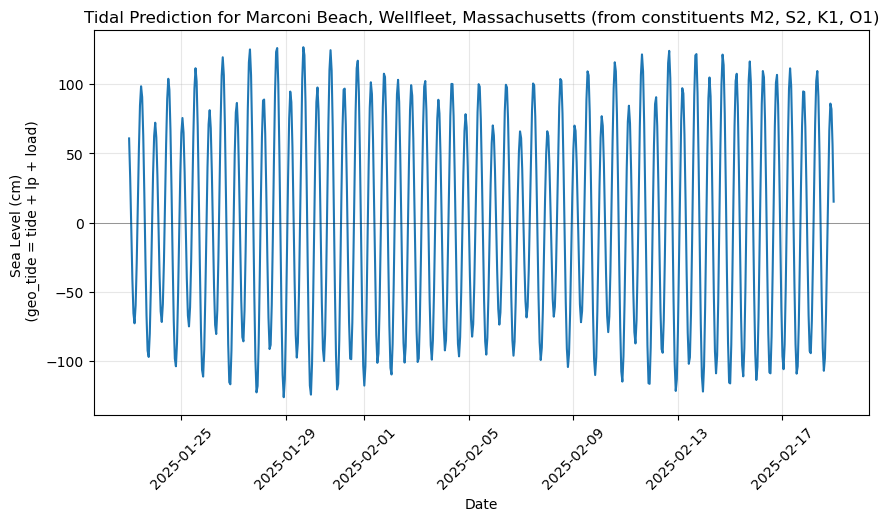

In [20]:

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(dates,geo_tide)
ax.grid(True, alpha=0.3)
ax.set_xlabel("Date")
plt.xticks(rotation=45)
ax.set_ylabel("Sea Level (cm) \n (geo_tide = tide + lp + load)")
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax.set_title('Tidal Prediction for Marconi Beach, Wellfleet, Massachusetts (from constituents M2, S2, K1, O1)')



In [28]:
import pandas as pd

df_out = pd.DataFrame({
    "Date": dates,
    "JulDay": cnes_julian_days,
    "Hour": hours,
    "Latitude": lats,
    "Longitude": lons,
    "Short_tide": tide,
    "LP_tide": lp,
    "Pure_Tide": tide + lp,
    "Geo_Tide": tide + lp + load,
    "Rad_Tide": load
})
df_out.to_csv("tide_output_01232025-02192025.csv", index=False)